# Clasificación de Churn Bancario con BERT

**Objetivo:** Predecir si un cliente bancario abandonará el banco (churn = 1) o se quedará (churn = 0)  
utilizando un modelo basado en BERT con fine-tuning para clasificación binaria.

**Arquitectura:**
- Modelo base: `bert-base-uncased` (Hugging Face Transformers)
- Framework: PyTorch
- Entrada: descripción textual de cada cliente
- Salida: probabilidad de churn

---
### 📋 Tabla de Contenidos
1. Instalación y configuración del entorno
2. Importación de librerías
3. Generación del dataset sintético
4. Preprocesamiento y construcción de texto
5. Tokenización con BertTokenizer
6. Dataset y DataLoader de PyTorch
7. Arquitectura del modelo BERT
8. Entrenamiento
9. Evaluación y métricas
10. Predicciones sobre nuevos clientes


## 1. Instalación y Configuración

Ejecutar esta celda solo la primera vez (especialmente en Google Colab).

In [1]:
# Instalar dependencias necesarias
# Descomentar si estás en Google Colab o un entorno sin estas librerías

# !pip install transformers torch scikit-learn pandas numpy matplotlib seaborn tqdm

## 2. Importación de Librerías

In [2]:
# === Librerías estándar ===
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# === PyTorch ===
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# === Hugging Face Transformers ===
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup

# === Scikit-learn ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# === Utilidades ===
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# === Reproducibilidad ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# === Configuración de dispositivo (GPU / CPU) ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Dispositivo activo: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

c:\Users\Leandro\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Dispositivo activo: cuda
   GPU: NVIDIA GeForce GTX 1650


## 3. Generación del Dataset Sintético

Simulamos un dataset realista de clientes bancarios con características típicas de modelos de churn:
- Variables demográficas (edad, género, país)
- Variables financieras (saldo, salario estimado)
- Variables de producto (número de productos, tarjeta de crédito)
- Variables de comportamiento (miembro activo, quejas recibidas)

La variable objetivo **churn** se genera con lógica de negocio realista.

In [ ]:
def generar_dataset(n=1500, seed=42):
    """
    Genera un dataset sintético de clientes bancarios con lógica
    de churn basada en reglas de negocio realistas.
    
    Returns:
        pd.DataFrame con n clientes y sus características.
    """
    np.random.seed(seed)
    random.seed(seed)

    paises   = ['España', 'Francia', 'Alemania']
    generos  = ['masculino', 'femenino']

    data = {
        'edad'             : np.random.randint(18, 75, n),
        'genero'           : np.random.choice(generos, n),
        'pais'             : np.random.choice(paises, n),
        'antiguedad_años'  : np.random.randint(0, 11, n),
        'saldo'            : np.round(np.random.uniform(0, 250000, n), 2),
        'num_productos'    : np.random.randint(1, 5, n),
        'tiene_tarjeta'    : np.random.choice([0, 1], n, p=[0.3, 0.7]),
        'miembro_activo'   : np.random.choice([0, 1], n, p=[0.4, 0.6]),
        'salario_estimado' : np.round(np.random.uniform(15000, 120000, n), 2),
        'quejas_recibidas' : np.random.choice([0, 1, 2, 3], n, p=[0.55, 0.25, 0.13, 0.07]),
        'uso_app_movil'    : np.random.choice([0, 1], n, p=[0.35, 0.65]),
        'score_credito'    : np.random.randint(300, 900, n),
    }

    df = pd.DataFrame(data)

    # ─── Lógica de churn con ruido aleatorio ───────────────────────────────
    def calcular_churn(row):
        prob = 0.15  # probabilidad base de churn

        # Factores que aumentan el riesgo de churn
        if row['quejas_recibidas'] >= 2:  prob += 0.35
        if row['miembro_activo']   == 0:  prob += 0.20
        if row['num_productos']    >= 3:  prob += 0.15
        if row['saldo']            == 0:  prob += 0.10
        if row['edad']             > 55:  prob += 0.10
        if row['pais']         == 'Alemania': prob += 0.08
        if row['antiguedad_años']  <= 1:  prob += 0.08
        if row['score_credito']    < 450: prob += 0.12

        # Factores que reducen el riesgo de churn
        if row['uso_app_movil']    == 1:  prob -= 0.10
        if row['tiene_tarjeta']    == 1:  prob -= 0.05
        if row['salario_estimado'] > 80000: prob -= 0.05

        prob = np.clip(prob, 0.02, 0.97)  # limitar entre 2% y 97%
        return int(np.random.random() < prob)

    df['churn'] = df.apply(calcular_churn, axis=1)
    return df


# Generar dataset
df = generar_dataset(n=1500)

print(f'Dataset generado: {df.shape[0]} clientes, {df.shape[1]} columnas')
print(f'\nDistribución de clases:')
churn_counts = df['churn'].value_counts()
for label, count in churn_counts.items():
    etiqueta = 'Churn (abandono)' if label == 1 else 'No Churn (retención)'
    print(f'   {etiqueta}: {count} ({count/len(df)*100:.1f}%)')

df.head()

📊 Dataset generado: 1500 clientes, 13 columnas

📈 Distribución de clases:
   No Churn (retención): 940 (62.7%)
   Churn (abandono): 560 (37.3%)


,edad,genero,pais,antiguedad_años,saldo,num_productos,tiene_tarjeta,miembro_activo,salario_estimado,quejas_recibidas,uso_app_movil,score_credito,churn
0,56,femenino,Alemania,2,176561.54,3,1,1,62306.34,3,0,538,1
1,69,masculino,España,0,155672.39,2,1,0,16222.71,2,0,633,0
2,46,femenino,Francia,5,247527.21,1,1,0,73465.28,0,1,448,0
3,32,masculino,Francia,7,77969.86,2,1,0,84460.05,0,1,707,0
4,60,femenino,Alemania,2,84992.97,4,1,1,77151.01,0,1,316,0


In [4]:
# Estadísticas descriptivas
df.describe().round(2)

,edad,antiguedad_años,saldo,num_productos,tiene_tarjeta,miembro_activo,salario_estimado,quejas_recibidas,uso_app_movil,score_credito,churn
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,46.30,5.07,123329.92,2.46,0.69,0.59,67438.36,0.75,0.63,603.87,0.37
std,16.41,3.19,71774.77,1.10,0.46,0.49,29818.08,0.95,0.48,172.09,0.48
min,18.00,0.00,7.68,1.00,0.00,0.00,15005.55,0.00,0.00,300.00,0.00
25%,32.00,2.00,61613.95,1.00,0.00,0.00,42140.16,0.00,0.00,455.00,0.00
50%,46.00,5.00,121129.82,2.00,1.00,1.00,67284.03,0.00,1.00,600.00,0.00
75%,61.00,8.00,184941.96,3.00,1.00,1.00,92641.10,1.00,1.00,755.00,1.00
max,74.00,10.00,249437.35,4.00,1.00,1.00,119948.04,3.00,1.00,899.00,1.00


## 4. Construcción de la Variable Textual

BERT trabaja con texto. Convertimos las variables numéricas y categóricas de cada cliente  
en una **descripción textual estructurada** que el modelo pueda procesar.

**Ejemplo de entrada:**  
`"edad: 45, genero: masculino, pais: España, antiguedad: 6 años, saldo: alto, productos: 2, tarjeta: sí, activo: no, quejas: 1, app movil: sí, score credito: 720"`

In [ ]:
def categorizar_saldo(saldo):
    """Convierte el saldo numérico a categoría descriptiva."""
    if saldo == 0:           return 'nulo'
    elif saldo < 50000:      return 'bajo'
    elif saldo < 120000:     return 'medio'
    elif saldo < 200000:     return 'alto'
    else:                    return 'muy alto'

def categorizar_salario(salario):
    """Convierte el salario estimado a categoría descriptiva."""
    if salario < 30000:      return 'bajo'
    elif salario < 60000:    return 'medio'
    elif salario < 90000:    return 'alto'
    else:                    return 'muy alto'

def categorizar_score(score):
    """Convierte el score de crédito a categoría descriptiva."""
    if score < 450:          return 'muy bajo'
    elif score < 600:        return 'bajo'
    elif score < 750:        return 'medio'
    else:                    return 'alto'

def cliente_a_texto(row):
    """
    Convierte una fila del DataFrame en una descripción textual
    que sirve como entrada para BERT.
    """
    quejas_texto = (
        'ninguna' if row['quejas_recibidas'] == 0
        else f"{row['quejas_recibidas']}"
    )

    texto = (
        f"edad: {row['edad']}, "
        f"genero: {row['genero']}, "
        f"pais: {row['pais']}, "
        f"antiguedad: {row['antiguedad_años']} años, "
        f"saldo: {categorizar_saldo(row['saldo'])}, "
        f"productos: {row['num_productos']}, "
        f"tarjeta credito: {'si' if row['tiene_tarjeta'] else 'no'}, "
        f"miembro activo: {'si' if row['miembro_activo'] else 'no'}, "
        f"salario: {categorizar_salario(row['salario_estimado'])}, "
        f"quejas: {quejas_texto}, "
        f"usa app movil: {'si' if row['uso_app_movil'] else 'no'}, "
        f"score credito: {categorizar_score(row['score_credito'])}"
    )
    return texto


# Aplicar transformación
df['texto_cliente'] = df.apply(cliente_a_texto, axis=1)

# Mostrar ejemplos
print('Ejemplos de textos generados:\n')
for i, row in df.sample(3, random_state=42).iterrows():
    estado = '🔴 CHURN' if row['churn'] == 1 else '🟢 NO CHURN'
    print(f'{estado} → {row["texto_cliente"]}')
    print()

📝 Ejemplos de textos generados:

🟢 NO CHURN → edad: 42, genero: masculino, pais: España, antiguedad: 4 años, saldo: medio, productos: 1, tarjeta credito: si, miembro activo: no, salario: bajo, quejas: 1, usa app movil: si, score credito: alto

🟢 NO CHURN → edad: 27, genero: femenino, pais: España, antiguedad: 3 años, saldo: bajo, productos: 2, tarjeta credito: no, miembro activo: no, salario: alto, quejas: ninguna, usa app movil: no, score credito: alto

🟢 NO CHURN → edad: 52, genero: femenino, pais: Francia, antiguedad: 9 años, saldo: alto, productos: 2, tarjeta credito: si, miembro activo: no, salario: alto, quejas: ninguna, usa app movil: si, score credito: medio



## 5.División Train / Test

In [ ]:
# Separar características y etiquetas
X = df['texto_cliente'].tolist()
y = df['churn'].tolist()

# División 80% train / 20% test, estratificada por clase
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f'Tamaño del conjunto de entrenamiento : {len(X_train)} muestras')
print(f'Tamaño del conjunto de prueba        : {len(X_test)} muestras')
print(f'\nDistribución en TRAIN:')
c = Counter(y_train)
print(f'   No Churn: {c[0]} ({c[0]/len(y_train)*100:.1f}%) | Churn: {c[1]} ({c[1]/len(y_train)*100:.1f}%)')
print(f'\nDistribución en TEST:')
c = Counter(y_test)
print(f'   No Churn: {c[0]} ({c[0]/len(y_test)*100:.1f}%) | Churn: {c[1]} ({c[1]/len(y_test)*100:.1f}%)')

📊 Tamaño del conjunto de entrenamiento : 1200 muestras
📊 Tamaño del conjunto de prueba        : 300 muestras

📈 Distribución en TRAIN:
   No Churn: 752 (62.7%) | Churn: 448 (37.3%)

📈 Distribución en TEST:
   No Churn: 188 (62.7%) | Churn: 112 (37.3%)


## 6.Tokenización con BertTokenizer

`BertTokenizer` convierte el texto en:
- **input_ids**: IDs de cada token en el vocabulario
- **attention_mask**: máscara indicando tokens reales vs. padding

Usamos `bert-base-uncased` (solo minúsculas, vocabulario en inglés de ~30K tokens).

In [ ]:
# Cargar tokenizador pre-entrenado
MODEL_NAME  = 'bert-base-uncased'
MAX_LEN     = 128  # longitud máxima de tokens por secuencia

print(f'Cargando tokenizador: {MODEL_NAME} ...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('✅ Tokenizador cargado correctamente.')

# Ejemplo de tokenización
ejemplo = X_train[0]
tokens = tokenizer(ejemplo, return_tensors='pt', truncation=True, max_length=MAX_LEN)
print(f'\nTexto de ejemplo:\n{ejemplo}')
print(f'\nNúmero de tokens: {tokens["input_ids"].shape[1]}')
print(f'   Tokens decodificados: {tokenizer.convert_ids_to_tokens(tokens["input_ids"][0][:20])}...')

⏳ Cargando tokenizador: bert-base-uncased ...
✅ Tokenizador cargado correctamente.

📝 Texto de ejemplo:
edad: 29, genero: femenino, pais: España, antiguedad: 0 años, saldo: bajo, productos: 3, tarjeta credito: no, miembro activo: si, salario: muy alto, quejas: 1, usa app movil: no, score credito: medio

🔢 Número de tokens: 79
   Tokens decodificados: ['[CLS]', 'ed', '##ad', ':', '29', ',', 'gene', '##ro', ':', 'fe', '##men', '##ino', ',', 'pa', '##is', ':', 'espana', ',', 'anti', '##gue']...


## 7. 🗂️ Dataset y DataLoader de PyTorch

Creamos una clase `Dataset` personalizada que encapsula la tokenización  
y construimos `DataLoader`s para iterar en minibatches durante el entrenamiento.

In [8]:
class ChurnDataset(Dataset):
    """
    Dataset de PyTorch para clasificación de churn.
    Tokeniza los textos con BertTokenizer y retorna tensores listos para el modelo.
    """

    def __init__(self, textos, etiquetas, tokenizer, max_len):
        self.textos     = textos
        self.etiquetas  = etiquetas
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        texto    = str(self.textos[idx])
        etiqueta = self.etiquetas[idx]

        # Tokenizar con padding y truncado automático
        encoding = self.tokenizer(
            texto,
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )

        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),       # [max_len]
            'attention_mask': encoding['attention_mask'].squeeze(0),  # [max_len]
            'label'         : torch.tensor(etiqueta, dtype=torch.long)
        }


# Hiperparámetros de entrenamiento
BATCH_SIZE  = 16
EPOCHS      = 3
LR          = 2e-5      # tasa de aprendizaje estándar para fine-tuning de BERT
WARMUP_STEPS_RATIO = 0.1  # 10% de steps para warmup

# Crear datasets
train_dataset = ChurnDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset  = ChurnDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'✅ Datasets creados:')
print(f'   Train: {len(train_dataset)} muestras | {len(train_loader)} batches de tamaño {BATCH_SIZE}')
print(f'   Test : {len(test_dataset)} muestras  | {len(test_loader)} batches de tamaño {BATCH_SIZE}')

✅ Datasets creados:
   Train: 1200 muestras | 75 batches de tamaño 16
   Test : 300 muestras  | 19 batches de tamaño 16


## 8.Arquitectura del Modelo BERT

Usamos `BertForSequenceClassification`, que añade una **capa de clasificación lineal**  
sobre el token `[CLS]` del encoder BERT.

```
Texto → [CLS] token₁ token₂ ... [SEP]
           ↓
      BERT Encoder (12 capas Transformer)
           ↓
   Representación [CLS] (768 dim)
           ↓
     Dropout + Linear
           ↓
   Logits [No Churn, Churn]
           ↓
      Softmax → Probabilidades
```

In [ ]:
# Cargar modelo BERT con cabeza de clasificación binaria
print(f'Cargando modelo: {MODEL_NAME} con 2 clases de salida ...')

modelo = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,         # clasificación binaria
    output_attentions=False,
    output_hidden_states=False
)

modelo = modelo.to(device)
print(f'✅ Modelo cargado y movido a {device}.')

# Resumen del modelo
total_params = sum(p.numel() for p in modelo.parameters())
trainable_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'\nParámetros totales      : {total_params:,}')
print(f'Parámetros entrenables  : {trainable_params:,}')

⏳ Cargando modelo: bert-base-uncased con 2 clases de salida ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9998.52it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

✅ Modelo cargado y movido a cuda.

🔢 Parámetros totales      : 109,483,778
🔢 Parámetros entrenables  : 109,483,778


## 9.Configuración del Optimizador y Scheduler

- **AdamW**: variante de Adam con decaimiento de pesos, recomendada para BERT  
- **Linear Warmup Scheduler**: aumenta la LR gradualmente al inicio para estabilizar el entrenamiento

In [ ]:
# Optimizador AdamW con weight decay
optimizer = AdamW(
    modelo.parameters(),
    lr=LR,
    eps=1e-8,
    weight_decay=0.01
)

# Total de pasos de entrenamiento
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_STEPS_RATIO)

# Scheduler con warmup lineal
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps    = warmup_steps,
    num_training_steps  = total_steps
)

# Función de pérdida
criterion = nn.CrossEntropyLoss()

print(f'Configuración de entrenamiento:')
print(f'   Épocas              : {EPOCHS}')
print(f'   Batch size          : {BATCH_SIZE}')
print(f'   Learning rate       : {LR}')
print(f'   Total pasos         : {total_steps}')
print(f'   Pasos de warmup     : {warmup_steps}')
print(f'   Loss function       : CrossEntropyLoss')

⚙️  Configuración de entrenamiento:
   Épocas              : 3
   Batch size          : 16
   Learning rate       : 2e-05
   Total pasos         : 225
   Pasos de warmup     : 22
   Loss function       : CrossEntropyLoss


## 10.Entrenamiento del Modelo

Funciones auxiliares para un epoch de entrenamiento y evaluación,  
seguido del bucle principal de entrenamiento.

In [11]:
def entrenar_epoch(modelo, loader, optimizer, scheduler, criterion, device):
    """
    Ejecuta un epoch de entrenamiento completo.
    Returns: pérdida media y accuracy del epoch.
    """
    modelo.train()
    total_loss, correctas, total = 0.0, 0, 0

    for batch in tqdm(loader, desc='  Entrenando', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = modelo(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        # Calcular pérdida
        loss = criterion(logits, labels)
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Gradient clipping para evitar explosión de gradientes
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        # Acumular métricas
        preds     = torch.argmax(logits, dim=1)
        correctas += (preds == labels).sum().item()
        total     += labels.size(0)

    return total_loss / len(loader), correctas / total


def evaluar(modelo, loader, criterion, device):
    """
    Evalúa el modelo sobre un DataLoader.
    Returns: pérdida media, accuracy, predicciones y etiquetas reales.
    """
    modelo.eval()
    total_loss, correctas, total = 0.0, 0, 0
    todas_preds, todas_labels    = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='  Evaluando ', leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = modelo(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits

            loss        = criterion(logits, labels)
            total_loss += loss.item()

            preds     = torch.argmax(logits, dim=1)
            correctas += (preds == labels).sum().item()
            total     += labels.size(0)

            todas_preds.extend(preds.cpu().numpy())
            todas_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correctas / total, todas_preds, todas_labels


print('✅ Funciones de entrenamiento y evaluación definidas.')

✅ Funciones de entrenamiento y evaluación definidas.


In [ ]:
# ─── Bucle principal de entrenamiento ──────────────────────────────────────
historial = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : []
}

mejor_val_acc = 0.0
mejor_modelo_estado = None

print(f'Iniciando entrenamiento: {EPOCHS} épocas\n')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    print(f'\n📍 Época {epoch}/{EPOCHS}')

    # Entrenamiento
    train_loss, train_acc = entrenar_epoch(
        modelo, train_loader, optimizer, scheduler, criterion, device
    )

    # Validación (usando test set como validación)
    val_loss, val_acc, _, _ = evaluar(modelo, test_loader, criterion, device)

    # Guardar historial
    historial['train_loss'].append(train_loss)
    historial['train_acc'].append(train_acc)
    historial['val_loss'].append(val_loss)
    historial['val_acc'].append(val_acc)

    # Guardar mejor modelo
    if val_acc > mejor_val_acc:
        mejor_val_acc = val_acc
        mejor_modelo_estado = modelo.state_dict().copy()
        print(f'   💾 Nuevo mejor modelo guardado (val_acc = {val_acc:.4f})')

    print(f'   Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}')
    print(f'   Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f}')

print('\n' + '=' * 65)
print(f'✅ Entrenamiento completado. Mejor val_acc: {mejor_val_acc:.4f}')

🚀 Iniciando entrenamiento: 3 épocas


📍 Época 1/3


   💾 Nuevo mejor modelo guardado (val_acc = 0.6267)
   Train → Loss: 0.6670 | Acc: 0.6183
   Val   → Loss: 0.6584 | Acc: 0.6267

📍 Época 2/3


   💾 Nuevo mejor modelo guardado (val_acc = 0.6800)
   Train → Loss: 0.6514 | Acc: 0.6333
   Val   → Loss: 0.5982 | Acc: 0.6800

📍 Época 3/3


   💾 Nuevo mejor modelo guardado (val_acc = 0.7067)
   Train → Loss: 0.6100 | Acc: 0.6725
   Val   → Loss: 0.5800 | Acc: 0.7067

✅ Entrenamiento completado. Mejor val_acc: 0.7067


## 11.Curvas de Aprendizaje

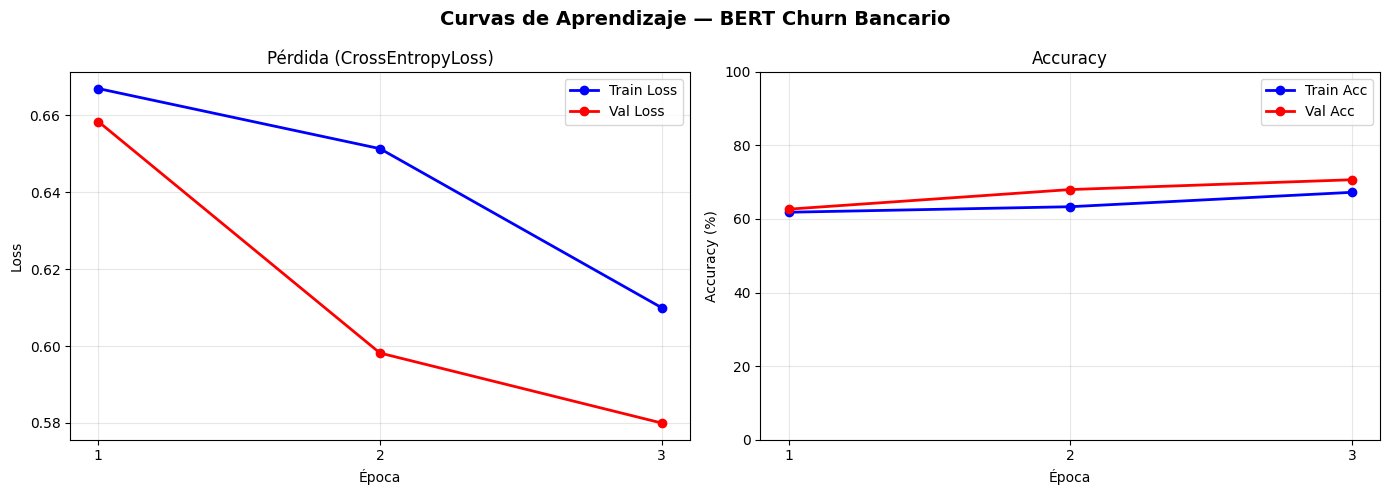

In [13]:
epocas = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizaje — BERT Churn Bancario', fontsize=14, fontweight='bold')

# ── Loss ──
axes[0].plot(epocas, historial['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epocas, historial['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Pérdida (CrossEntropyLoss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epocas)

# ── Accuracy ──
axes[1].plot(epocas, [a*100 for a in historial['train_acc']], 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epocas, [a*100 for a in historial['val_acc']],   'r-o', label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epocas)
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.show()

## 12.Evaluación Final con el Mejor Modelo

In [ ]:
# Cargar los pesos del mejor modelo
modelo.load_state_dict(mejor_modelo_estado)

# Evaluación final sobre el conjunto de prueba
test_loss, test_acc, y_pred, y_true = evaluar(modelo, test_loader, criterion, device)

# Calcular métricas
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
accuracy  = accuracy_score(y_true, y_pred)

print('=' * 55)
print('REPORTE DE EVALUACIÓN FINAL (conjunto de prueba)')
print('=' * 55)
print(f'  Accuracy   : {accuracy  :.4f} ({accuracy*100:.2f}%)')
print(f'  Precision  : {precision :.4f}')
print(f'  Recall     : {recall    :.4f}')
print(f'  F1-Score   : {f1        :.4f}')
print(f'  Test Loss  : {test_loss :.4f}')
print('=' * 55)

print('\nReporte completo de clasificación:')
print(classification_report(
    y_true, y_pred,
    target_names=['No Churn (0)', 'Churn (1)']
))

📊 REPORTE DE EVALUACIÓN FINAL (conjunto de prueba)
  Accuracy   : 0.7067 (70.67%)
  Precision  : 0.6333
  Recall     : 0.5089
  F1-Score   : 0.5644
  Test Loss  : 0.5800

📋 Reporte completo de clasificación:
              precision    recall  f1-score   support

No Churn (0)       0.74      0.82      0.78       188
   Churn (1)       0.63      0.51      0.56       112

    accuracy                           0.71       300
   macro avg       0.69      0.67      0.67       300
weighted avg       0.70      0.71      0.70       300



### Matriz de Confusión

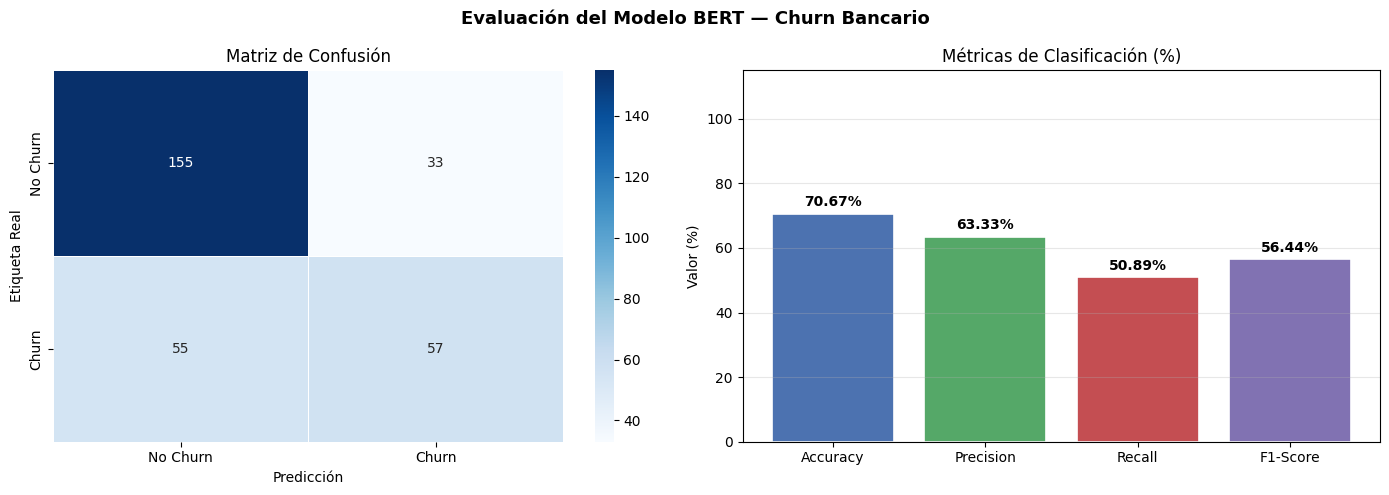

In [15]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación del Modelo BERT — Churn Bancario', fontsize=13, fontweight='bold')

# ── Matriz de confusión ──
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Etiqueta Real')
axes[0].set_xlabel('Predicción')

# ── Barras de métricas ──
metricas  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores   = [accuracy, precision, recall, f1]
colores   = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars = axes[1].bar(metricas, [v * 100 for v in valores], color=colores, edgecolor='white', linewidth=1.2)
axes[1].set_ylim(0, 115)
axes[1].set_title('Métricas de Clasificación (%)')
axes[1].set_ylabel('Valor (%)')
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, valores):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{val*100:.2f}%',
        ha='center', va='bottom', fontweight='bold'
    )

plt.tight_layout()
plt.show()

## 13.Predicciones sobre Nuevos Clientes

Función reutilizable para predecir el riesgo de churn de un cliente nuevo,  
con probabilidad de cada clase.

In [ ]:
def predecir_churn(texto_cliente, modelo, tokenizer, device, max_len=128):
    """
    Predice la probabilidad de churn para un cliente dado su descripción textual.
    
    Args:
        texto_cliente: str con la descripción del cliente
        modelo       : modelo BERT entrenado
        tokenizer    : tokenizador BERT
        device       : cpu o cuda
        max_len      : longitud máxima de tokens
    
    Returns:
        dict con predicción, probabilidades y etiqueta
    """
    modelo.eval()

    encoding = tokenizer(
        texto_cliente,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = modelo(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_clase = int(np.argmax(probs))
    etiqueta   = '🔴 CHURN' if pred_clase == 1 else '🟢 NO CHURN'

    return {
        'prediccion'     : pred_clase,
        'etiqueta'       : etiqueta,
        'prob_no_churn'  : round(float(probs[0]) * 100, 2),
        'prob_churn'     : round(float(probs[1]) * 100, 2)
    }


# ─── Casos de prueba ────────────────────────────────────────────────────────
casos_prueba = [
    {
        'descripcion': 'Cliente joven con buen comportamiento',
        'texto': 'edad: 28, genero: masculino, pais: España, antiguedad: 5 años, '
                 'saldo: medio, productos: 2, tarjeta credito: si, '
                 'miembro activo: si, salario: alto, quejas: ninguna, '
                 'usa app movil: si, score credito: alto'
    },
    {
        'descripcion': 'Cliente mayor con señales de abandono',
        'texto': 'edad: 62, genero: femenino, pais: Alemania, antiguedad: 1 años, '
                 'saldo: nulo, productos: 4, tarjeta credito: no, '
                 'miembro activo: no, salario: bajo, quejas: 3, '
                 'usa app movil: no, score credito: muy bajo'
    },
    {
        'descripcion': 'Cliente con perfil mixto',
        'texto': 'edad: 45, genero: masculino, pais: Francia, antiguedad: 4 años, '
                 'saldo: alto, productos: 2, tarjeta credito: si, '
                 'miembro activo: no, salario: medio, quejas: 1, '
                 'usa app movil: si, score credito: medio'
    }
]

print('PREDICCIONES SOBRE NUEVOS CLIENTES')
print('=' * 65)

for caso in casos_prueba:
    resultado = predecir_churn(caso['texto'], modelo, tokenizer, device)
    print(f"\n📌 {caso['descripcion']}")
    print(f"   Texto: {caso['texto'][:80]}...")
    print(f"   Predicción  : {resultado['etiqueta']}")
    print(f"   Prob. No Churn : {resultado['prob_no_churn']}%")
    print(f"   Prob. Churn    : {resultado['prob_churn']}%")

🔮 PREDICCIONES SOBRE NUEVOS CLIENTES

📌 Cliente joven con buen comportamiento
   Texto: edad: 28, genero: masculino, pais: España, antiguedad: 5 años, saldo: medio, pro...
   Predicción  : 🟢 NO CHURN
   Prob. No Churn : 84.56%
   Prob. Churn    : 15.44%

📌 Cliente mayor con señales de abandono
   Texto: edad: 62, genero: femenino, pais: Alemania, antiguedad: 1 años, saldo: nulo, pro...
   Predicción  : 🔴 CHURN
   Prob. No Churn : 32.89%
   Prob. Churn    : 67.11%

📌 Cliente con perfil mixto
   Texto: edad: 45, genero: masculino, pais: Francia, antiguedad: 4 años, saldo: alto, pro...
   Predicción  : 🟢 NO CHURN
   Prob. No Churn : 74.04%
   Prob. Churn    : 25.96%


## 14.Guardar el Modelo

Guardamos el modelo entrenado para reutilizarlo sin necesidad de re-entrenar.

In [ ]:
import os

SAVE_DIR = './bert_churn_modelo'
os.makedirs(SAVE_DIR, exist_ok=True)

# Guardar modelo y tokenizador
modelo.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f'✅ Modelo guardado en: {SAVE_DIR}/')
print(f'   Archivos: {os.listdir(SAVE_DIR)}')

# Para cargar el modelo más adelante:
print('\nPara cargar el modelo en el futuro:')
print("""
from transformers import BertForSequenceClassification, BertTokenizer

modelo    = BertForSequenceClassification.from_pretrained('./bert_churn_modelo')
tokenizer = BertTokenizer.from_pretrained('./bert_churn_modelo')
""")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.87it/s]

✅ Modelo guardado en: ./bert_churn_modelo/
   Archivos: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']

📋 Para cargar el modelo en el futuro:

from transformers import BertForSequenceClassification, BertTokenizer

modelo    = BertForSequenceClassification.from_pretrained('./bert_churn_modelo')
tokenizer = BertTokenizer.from_pretrained('./bert_churn_modelo')



## 15.Resumen y Próximos Pasos

### ✅ Lo que implementamos

| Componente | Detalle |
|---|---|
| Dataset | 1,500 clientes sintéticos con lógica de negocio realista |
| Texto de entrada | Descripción estructurada de 12 variables por cliente |
| Modelo | `bert-base-uncased` con capa de clasificación binaria |
| Optimizador | AdamW + Linear Warmup Scheduler |
| Loss | CrossEntropyLoss |
| Métricas | Accuracy, Precision, Recall, F1, Matriz de Confusión |
| Hardware | CPU/GPU automático con `torch.device` |

### Próximos Pasos Recomendados

1. **Datos reales**: Reemplazar el dataset sintético por datos reales del banco  
2. **Modelo multilingüe**: Cambiar a `bert-base-multilingual-cased` si los datos son en español  
3. **Más épocas**: Aumentar a 5-10 epochs con early stopping  
4. **Balanceo de clases**: Usar `WeightedRandomSampler` si el desbalance es severo  
5. **Hyperparameter tuning**: Grid search sobre LR, batch size, max_len  
6. **Modelos alternativos**: Probar `RoBERTa`, `DistilBERT` (más rápido) o `XLM-RoBERTa`  
7. **Interpretabilidad**: Usar SHAP o LIME sobre los embeddings para explicar predicciones  
8. **API REST**: Servir el modelo con FastAPI o Flask para integración en producción  

---
*Notebook desarrollado con PyTorch + Hugging Face Transformers*